Dataset shape: (20640, 8)
Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Train size: 16512, Test size: 4128

Model coefficients (weights): [ 4.48674910e-01  9.72425752e-03 -1.23323343e-01  7.83144907e-01
 -2.02962058e-06 -3.52631849e-03 -4.19792487e-01 -4.33708065e-01]
Intercept (bias): -37.023277706063794

MSE  = 0.5559
RMSE = 0.7456
R²   = 0.5758


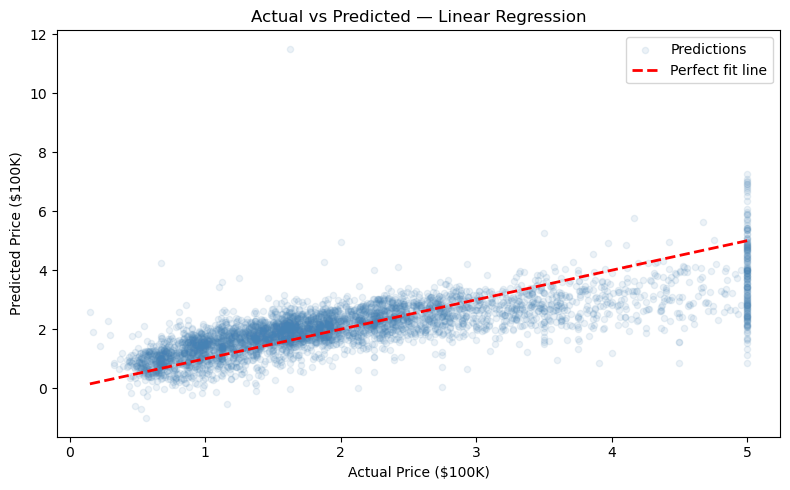

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing   # Boston is deprecated
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
# STEP 1: Load the dataset
data = fetch_california_housing()
X = data.data        # Features: MedInc, HouseAge, AveRooms, etc.
y = data.target      # Target: median house value

print("Dataset shape:", X.shape)       # (20640, 8)
print("Feature names:", data.feature_names)
# STEP 2: Split into train / test sets (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")
# STEP 3: Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)   # ← learns coefficients here
print("\nModel coefficients (weights):", model.coef_)
print("Intercept (bias):", model.intercept_)
# STEP 4: Predict on test data
y_pred = model.predict(X_test)   # ŷ = X_test @ w + b
# STEP 5: Evaluate with RMSE and R²
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)        # Back to original unit ($100K)
r2   = r2_score(y_test, y_pred)

print(f"\nMSE  = {mse:.4f}")   # Average squared error
print(f"RMSE = {rmse:.4f}")   # ≈ average error in $100K units
print(f"R²   = {r2:.4f}")     # 1.0 = perfect, 0 = no better than mean
# STEP 6: Plot Actual vs Predicted (TASK 4 requirement)
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.1, color='steelblue', s=20, label='Predictions')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2, label='Perfect fit line')
plt.xlabel("Actual Price ($100K)")
plt.ylabel("Predicted Price ($100K)")
plt.title("Actual vs Predicted — Linear Regression")
plt.legend()
plt.tight_layout()
plt.show()

# INTERPRETATION:
# • If all dots lie on the red line → perfect model
# • Dots spread away from the line → prediction errors
# • R² ≈ 0.58 means 58% of price variance is explained

Class distribution: [100  50]
Coefficients (weights): [[-2.38791011 -2.09062933]]
Intercept: [-2.60638646]

First 10 predicted labels: [0 1 0 0 0 1 0 0 0 0]
First 10 probabilities: [0.018 0.933 0.    0.01  0.009 0.933 0.06  0.    0.01  0.053]


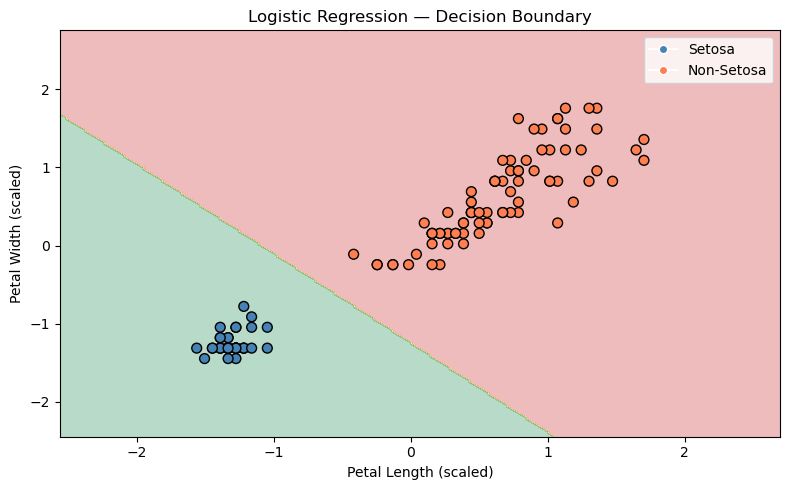

In [2]:
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

iris = load_iris()
X = iris.data    # 4 features: sepal_length, sepal_width, petal_length, petal_width
y_multi = iris.target   # 0=Setosa, 1=Versicolor, 2=Virginica
# Convert to binary: Setosa(0) → 1, everything else → 0
y = (y_multi == 0).astype(int)

print("Class distribution:", np.bincount(y))
# STEP 2: Use only 2 features for easy visualisation
# -----------------------------------------------------------
# Petal length (index 2) and petal width (index 3) work best
X_vis = X[:, [2, 3]]   # shape: (150, 2)

# -----------------------------------------------------------
# STEP 3: Train/Test split
# -----------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_vis, y, test_size=0.2, random_state=42
)
# STEP 4: Feature Scaling — VERY IMPORTANT for Logistic Reg
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  # fit + transform on train
X_test  = scaler.transform(X_test)       # only transform on test (no data leak!)
# STEP 5: Train Logistic Regression
clf = LogisticRegression(random_state=42, max_iter=200)
clf.fit(X_train, y_train)

print("Coefficients (weights):", clf.coef_)
print("Intercept:", clf.intercept_)
# STEP 6: Predictions
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]  # probability of being Setosa

print("\nFirst 10 predicted labels:", y_pred[:10])
print("First 10 probabilities:", y_prob[:10].round(3))
# STEP 7: Plot Decision Boundary
h = 0.02   # Step size for mesh grid
x_min, x_max = X_train[:, 0].min()-1, X_train[:, 0].max()+1
y_min, y_max = X_train[:, 1].min()-1, X_train[:, 1].max()+1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# Predict class for every point in the mesh grid
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(8, 5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlGn')  # shaded regions

# Plot actual training points
colors = ['coral' if label==0 else 'steelblue' for label in y_train]
plt.scatter(X_train[:, 0], X_train[:, 1],
            c=colors, edgecolors='k', s=50, label='Training points')

plt.xlabel("Petal Length (scaled)")
plt.ylabel("Petal Width (scaled)")
plt.title("Logistic Regression — Decision Boundary")
plt.legend(handles=[
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue', label='Setosa'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='coral',     label='Non-Setosa')
])
plt.tight_layout()
plt.show()

Confusion Matrix:
 [[20  0]
 [ 0 10]]


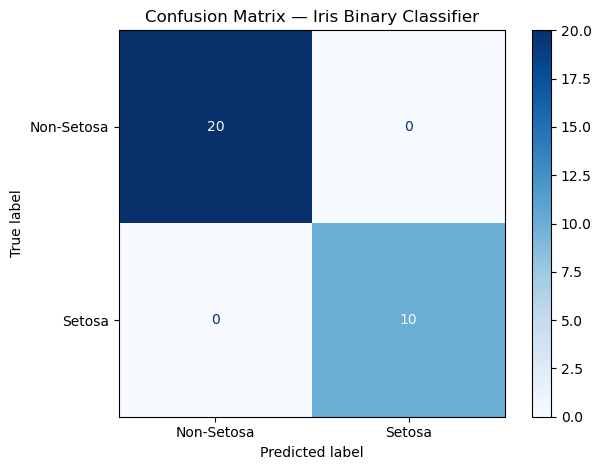


Classification Report:
              precision    recall  f1-score   support

  Non-Setosa       1.00      1.00      1.00        20
      Setosa       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Overall Accuracy: 100.00%


In [3]:
# TASK 3: Metrics — Classification Report & Confusion Matrix
from sklearn.metrics import (classification_report,
                              confusion_matrix,
                              ConfusionMatrixDisplay,
                              accuracy_score)
import matplotlib.pyplot as plt

# (Continuing from Task 2 — clf, X_test, y_test, y_pred are ready)

# -----------------------------------------------------------
# CONFUSION MATRIX
# -----------------------------------------------------------
#           Predicted Non-Setosa | Predicted Setosa
# Actual Non-Setosa   TN        |       FP
# Actual Setosa       FN        |       TP
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Visualise it with a nice heatmap
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Non-Setosa', 'Setosa'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix — Iris Binary Classifier")
plt.tight_layout()
plt.show()

report = classification_report(y_test, y_pred,
                                target_names=['Non-Setosa', 'Setosa'])
print("\nClassification Report:")
print(report)

# INDIVIDUAL METRIC EXTRACTION

acc = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {acc * 100:.2f}%")


Total students: 300
Pass: 194, Fail: 106

Sample data:
 hours_studied  previous_score  attendance_% result
           4.4            33.6          58.4   Fail
           9.6            67.2          63.9   Pass
           7.6            67.8          58.9   Pass
           6.4            74.6          54.4   Pass
           2.4            80.8          56.0   Fail
           2.4            98.3          73.0   Pass
           1.5            66.1          60.3   Fail
           8.8            52.6          68.2   Pass

=== 80/20 Split Results ===
              precision    recall  f1-score   support

        Fail       0.94      0.77      0.85        22
        Pass       0.88      0.97      0.93        38

    accuracy                           0.90        60
   macro avg       0.91      0.87      0.89        60
weighted avg       0.90      0.90      0.90        60


New student — Hours: 7.5, Score: 72, Attendance: 85%
Prediction: PASS ✓
Pass probability: 99.7%
Fail probability: 0.3%



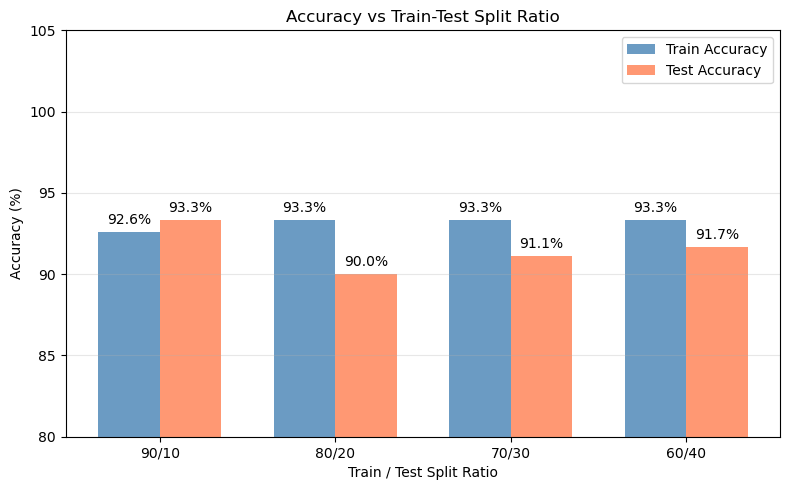

In [4]:
# ============================================================
# PRACTICE SHEET: Student Exam Pass/Fail Predictor
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# -----------------------------------------------------------
# PART A: Create synthetic student dataset
# -----------------------------------------------------------
np.random.seed(42)
n_students = 300

hours_studied   = np.random.uniform(1, 10, n_students)    # 1–10 hours
previous_score  = np.random.uniform(30, 100, n_students)  # 30–100 marks
attendance_pct  = np.random.uniform(50, 100, n_students)  # 50–100%

# Rule: pass if weighted score > 70 (with some noise)
score = (hours_studied * 5 +
         previous_score * 0.4 +
         attendance_pct * 0.3 +
         np.random.normal(0, 5, n_students))
y = (score > 70).astype(int)   # 1 = Pass, 0 = Fail

X = np.column_stack([hours_studied, previous_score, attendance_pct])

print(f"Total students: {n_students}")
print(f"Pass: {y.sum()}, Fail: {(y==0).sum()}")

# Create a DataFrame for easy inspection
df = pd.DataFrame({
    'hours_studied': hours_studied.round(1),
    'previous_score': previous_score.round(1),
    'attendance_%': attendance_pct.round(1),
    'result': ['Pass' if v else 'Fail' for v in y]
})
print("\nSample data:")
print(df.head(8).to_string(index=False))

# -----------------------------------------------------------
# PART B: Standard 80/20 Split — Full pipeline
# -----------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

model = LogisticRegression(random_state=42, max_iter=500)
model.fit(X_train_sc, y_train)

y_pred = model.predict(X_test_sc)
print("\n=== 80/20 Split Results ===")
print(classification_report(y_test, y_pred, target_names=['Fail','Pass']))

# Predict for a new student
new_student = np.array([[7.5, 72, 85]])   # 7.5 hrs, score 72, 85% attendance
new_scaled  = scaler.transform(new_student)
pred   = model.predict(new_scaled)[0]
prob   = model.predict_proba(new_scaled)[0]

print(f"\nNew student — Hours: 7.5, Score: 72, Attendance: 85%")
print(f"Prediction: {'PASS ✓' if pred==1 else 'FAIL ✗'}")
print(f"Pass probability: {prob[1]*100:.1f}%")
print(f"Fail probability: {prob[0]*100:.1f}%")

# -----------------------------------------------------------
# PART C: Compare different train/test split ratios
# -----------------------------------------------------------
split_ratios = [0.10, 0.20, 0.30, 0.40]   # test sizes
train_accs, test_accs = [], []

print("\n=== Split Ratio Comparison ===")
print(f"{'Split':>10}  {'Train Samples':>14}  {'Test Samples':>12}  {'Train Acc':>10}  {'Test Acc':>9}")
print("-" * 62)

for test_sz in split_ratios:
    Xtr, Xte, ytr, yte = train_test_split(
        X, y, test_size=test_sz, random_state=42
    )
    sc = StandardScaler()
    Xtr_s = sc.fit_transform(Xtr)
    Xte_s = sc.transform(Xte)

    m = LogisticRegression(random_state=42, max_iter=500)
    m.fit(Xtr_s, ytr)

    tr_acc = accuracy_score(ytr, m.predict(Xtr_s)) * 100
    te_acc = accuracy_score(yte, m.predict(Xte_s)) * 100
    train_accs.append(tr_acc)
    test_accs.append(te_acc)

    ratio_label = f"{int((1-test_sz)*100)}/{int(test_sz*100)}"
    print(f"{ratio_label:>10}  {len(Xtr):>14}  {len(Xte):>12}  {tr_acc:>9.2f}%  {te_acc:>8.2f}%")

# -----------------------------------------------------------
# PART D: Plot the split comparison
# -----------------------------------------------------------
labels = ['90/10', '80/20', '70/30', '60/40']
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, train_accs, width, label='Train Accuracy', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, test_accs,  width, label='Test Accuracy',  color='coral',     alpha=0.8)

# Add value labels on bars
for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%',
            ha='center', va='bottom', fontsize=10)

ax.set_xlabel("Train / Test Split Ratio")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Accuracy vs Train-Test Split Ratio")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(80, 105)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# -----------------------------------------------------------
# KEY OBSERVATIONS
# -----------------------------------------------------------
# • Train accuracy is always ≥ test accuracy (model memorises training data)
# • 90/10: high train acc but unreliable test (only 30 test samples)
# • 80/20: good balance — industry standard choice
# • 60/40: lower train acc because model has less data to learn from
# • Gap between train & test accuracy = degree of overfitting